# 09. Naive News Letter Delivery

## 09.01. User Stories Are Not Set In Stone

##### 09.01.0.1. Skimming: What did you notice and why? Any Questinos

_**What?**_  
It is a great habbit to revisit user stories and refine them as we get more precise about implementation.  
Author makes note of how we now have `confirmed` subscribers and subcribers `pending_confirmation`.  

Now that we are building out our newsletter email delivery we use more precise language to articulate that we only want  
to deliver send out emails to only confirmed subscribers.

_**Why?**_  
I've encountered this in my experience how a user story gets more clear implemetation occurs.

This looks a little different pre-AI and now currently with AI, because with AI now we can dig deeper and refine a PRD as we  
flesh out supporting documents like the ADRs, Data Model, API spec, testing strategy, ci-cd documentation and project structure.  
When this is done before writing any code, there's a lot of clarify to agents, developers and product ownwers about what is built  
from a high level to the granular details.

_**Questions**_  
I wonder how the appropriate amount of time to spend on refining a PRD especially now in the age of AI before writing any code.   
Because before it was usually the case that a lot of things would get discovered while development was happening. Because of the  
speed at which we can generate code now it seems that you can have moved too quickly before refining the implementation. Sometimes  
by the time you're revisiting the work, it feels like you have to start from scratch.

I guess the question is it more worth it currently to do the documentation work upfront, identify the core of a product and refine  
that, so that the first iteration is surgical and extensible? In other words fleshing our a core that is both backward and forward compatible  
with a docuumentation first approach that allows one to clearly define (as best as possible) what the core should look like.

Here it means then that humans can become the bottleneck as well, either going too fast to truly define the core, or too slow to leverage  
what can be done with AI. Something optimal is somewhere inbetween the two. One thing is for sure, clarity is super benefitial for humans   
but now even more when couple with AI.

##### 09.01.0.0.1. Deep Dive: Summarize, ELI5, Connect

## 09.02. Do Not Spam Unconfirmed Subscribers

##### 09.02.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
The **scoped mock** that is we create with `.mount_as_scoped` and name with `named` that is used in `create_unconfirmed_subscriber`.

_**Why?**_  
It seems like they help with ensuring that we drive the state of our application cleanly because they are local to the helpers they  
are created within.

_**Questions?**_  
None

##### 09.02.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Primarily 
- Add `newsletter_not_sent_to_unconfirmed_subscriber()` - Thing to note is that we expect 0 from our mock email server
- Add `create_unconfirmed_subscriber` - Thing to note here is we create a scoped mock/mount of the test `app.email_server`
- Add the `publish_newsletter` handler in newly created `src/routes/newsletter.rs` module.

Talk about scoped mocks and using public facing api already in place via the `subscribe` handler for `POST /subscriptions` that adds a new subscriber and  
clicking the confirmation link that confirms a subscriber

Let start by implementing `newsletter_are_not_delivered_to_unconfirmed_subscribers` and `create_unconfirmed_subscriber;
```Rust
//! src/api/main.rs
// [...]
// New test module

mod newsletter;

//! api/routes/newsletter.rs
use crate::common::{spawn_app, TestApp};
use wiremock::{ Mock, ResponseTemplate, matchers::{any, path, method}};

#[tokio::test]
async fn newsletters_not_delivered_to_unconfirmed_subscribers() {
    // Arrange
    let app = spawn_app().await;
    create_unconfirmed_subscriber(&app).await;
    
    // Act
    Mock::given(any())
        .respond_with(ResponseTemplate::new(200))
        // asserted at the end of the scope 
        // that no request is fired at Postmark
        .expect(0) 
        .mount(&app.email_server)
        .await;

    // A sketch of the newsletter payload structure
    let newsletter_request_body = serd_json::json!({
        "title": "Newsletter title",
        "content" : {
           "text": "Newsletter body as plain text",
            "html": "<p>Newsletter body as HTML</p>"
       }
    });

    let response = request::Client::new()
        .post(format!("{}/newsletters", &app.address))
        .json(newsletter_request_body)
        .send()
        .await
        .expect("Failed to execute newsletter post request");
    
    // Assert
    assert_eq!(response.status().as_u16(), 200);
    // Mock verifies on Drop that we havn't sent the newsletter email
}

/// Use the public API (via subscribe handler) of the application under test to
// create an unconfirmed subscriber
async fn create_unconfirmed_subscriber(app: &TestApp) {
    let body = "username=lei%20yin&email=lei_yin_loo%40gmail.com";

    let _mock_guard = Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .named("Mock email server for creating unconfirmed subscriber")
        .expect(1)
        .mount_as_scoped(&app.email_server)
        .await;
    
   app.post_subscriptions(body.into())
       .await
       .error_for_status()
       .expect("Failed to post subscription when creating unconfirmed user.");
}
```
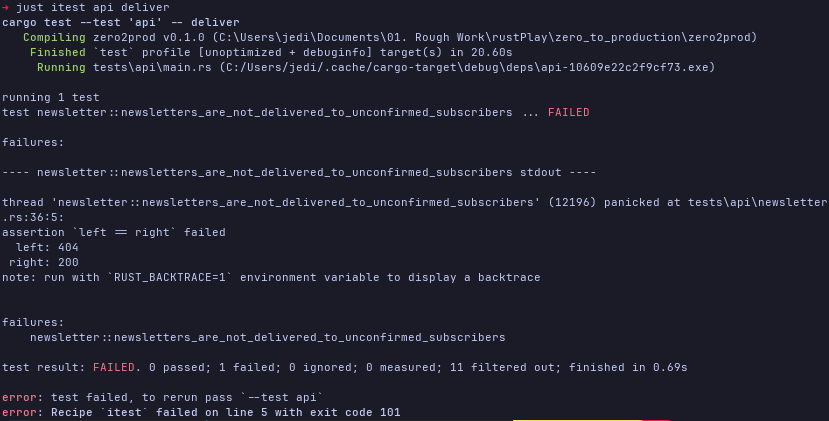

This should return a 404 because we have not handled the `POST /newsletters` route.

To go green we just add the handler and update the `Router`.
```Rust
//! src/routes/mod.rs
// [...]
mod newsletter;

// [...]
pub use newsletter::*;

//! src/routes/newsletter.rs
use actix_web::HttpResponse;

#[tracing::instrument(
    name = "Publish newsletter"
)]
pub async fn publish_newsletter() -> HttpResponse {
    HttpResponse::Ok().finish()
}
```

```Rust
//! src/ startup.rs
// [...]
use crate::routes{/**/, publish_newsletter};

fn run(/**/) -> Result<Server, std::io::Error> {
    // [...]
    let server = HttpServer::new(move || {
        App::new()
            .wrap(TracingLogger::default())
            // Registering the new handler
            .route("/newsletters", web::post().to(post_newsletter))
            // [...]
    })
    // [...]
}
```

### 9.02.0 Overview

### 9.02.1. Set Up State Using The Public API

##### 09.02.1.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Here we take note that we are using our public api `POST /subscriptions` that we are using to create a new subscriber by triggering the `subscribe` handler via the  
`app.post_subscriptions()` method we defined on `TestApp`

### 9.02.3. Scoped Mocks

##### 09.02.3.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
We take a look `_mock_guard` and how it helps us create a localized email server that we can spin up and dispose for the sole purpose
of creating a new subscriber which helps us drive the state of the application in a clean and localized way.

```Rust
//! tests/api/newsletter.rs
// [...]
async fn create_unconfirmed_subscriber(app: &TestApp) {
    // [...]
    _mock_guard = Mock::given(path("/email"))
        .and(method(""))
        .respond_with(ResponseTemplate::new(200))
        .name("Create unconfirmed subscriber")
        .expect(1)
        .mount_as_scoped(&app.email_server)
        .await;
}
```

### 9.02.4 Green Test

##### 09.02.4.1. Deep Dive: Summarize, ELI5, Connect

Pretty straight forward. All we have to do is add a new module `src/routes/newsletter.rs` and implement it as follows  
```Rust
//! src/routes/mod.rs
// [...]
mod newsletter;

// [...]
pub use newsletter::*;

//! src/routes/newsletter.rs
use actix_web::HttpResponse;

#[tracing::instrument(
    name = "Publish newsletter"
)]
pub async fn publish_newsletter() -> HttpResponse {
    HttpResponse::Ok().finish()
}
```

Finally we add a new route for the hander in `src/startup.rs`'s  `run` function

## 09.03. All Confirmed Subscribers Receive New Issues

### 09.03.1. Composing Test Helpers

##### 09.03.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
How we modify `creat_unconfirmed_subscriber()` and reuse it in `create_confirmed_subscriber`

_**Why?**_  
Just a small clever change enables us to drive the application state without code duplication.

_**Questions**_
None

##### 09.03.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  

Primarily 
- Update our implementation of `create_unconfirmed_subscriber` by returning confirmation links in order to reuse with `create_confirmed_subscriber`
- Add `newsletter_sent_to_confirmed_subscriber` test

##### 09.03.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Primarily updating `create_unconfirmed_subscriber` to return `ConfirmationLinks` that we can use with `create_confirmed_subscriber`.
```Rust
//! tests/api/newsletter.rs
// [...]

async fn create_unconfirmed_subscriber(app: &TestApp) -> ConfirmationLinks {
    let body = "username=lei%20loo&email=lei_yin_loo%40gmail.com";

    let _mock_guard = Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .named("Create unconfirmed subscriber")
        .expect(1)
        .mount_as_scoped(&app.email_server)
        .await;

    app.post_subscriptions(body.into());

    let received_request = &app.email_server.received_requests().await.unwrap().pop().unwrap();
    app.get_confirmation_links(received_request)
}

async fn create_confirmed_subscriber(app: &TestApp) {
    let confirmation_links = create_unconfirmed_subscriber(app);
    reqwest::get(confirmation_links.html)
        .await
        .unwrap()
        .error_for_status()
        .unwrap();
}
```

We can then use the `create_confirmed_subscriber` to test that newsletters will be delivered to confirmed subscribers
```Rust
//! tests/api/newsletter.rs
// [...]

#[tokio::test]
async fn newsletters_are_delivered_to_confirmed_subscribers(){
    let app = spawn_app().await;
    create_confirmed_subscriber();

    Mock::given(path("/email"))
        .and(method("POST"))
        .responde_with(ResponseTemplate::new(200))
        .expect(1)
        .mount(&app.email_server)
        .await;

    let newsletter_request_body = serde_json::json!({
        "title": "Newsletter title",
        "content": {
            "plain": "Newsletters as plain text",
            "html": "<p>Newsletters as HTML</p>"
        }
    });

    let response = reqwest::Client::new()
        .post(format!("{}/newsletters", &app.address))
        .json(&newsletter_request_body)
        .send()
        .await
        .expect("Failed to execute publish newsletter request in test.");

    assert_eq!(response.status().as_u16(), 200);
}
```

This should faile because as of yet our `publish_newsletter` handler is not sending emails to our confirmed subscribers  
which is what we work on in the next sections of the chapter.  

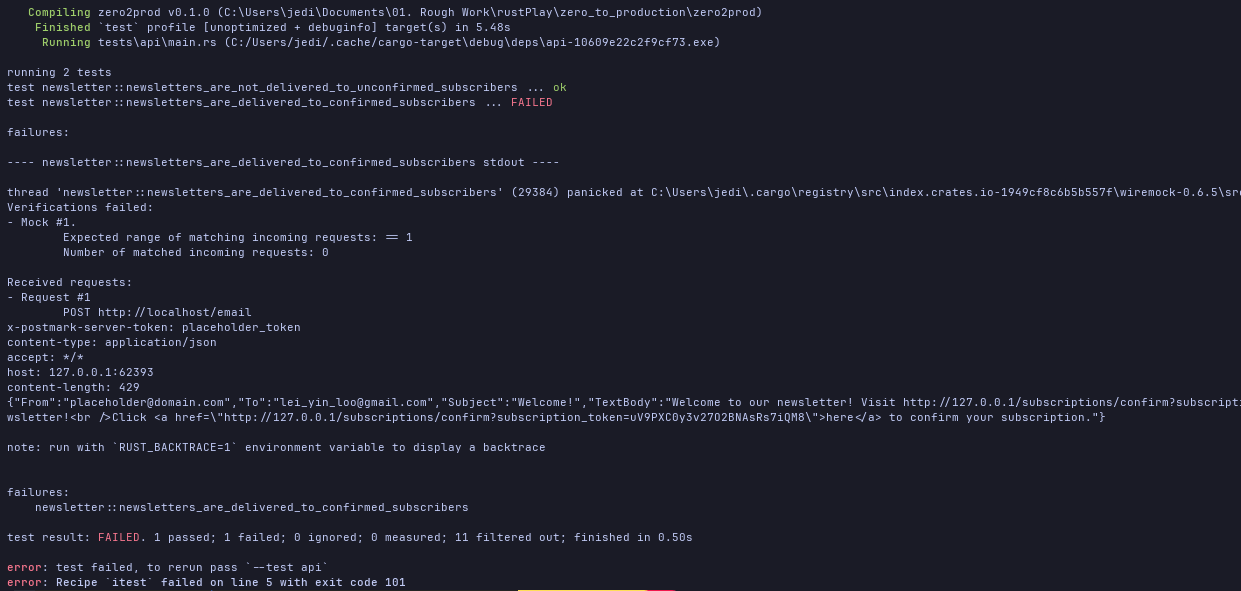

## 09.04. Implementation Strategy

##### 09.04.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
Simple naive approach that iterates through all confirmed subscribers and sends an email with newsletter issue

_**Why?**_  
Simplicity of the the naive strategy

##### 09.04.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
_The plan_  
1. Process newsletter issue details as a body of incoming API call;
2. Get all confirmed subscribers
3. Send email via Postmark with newsletter iteratively

## 09.05. Body Schema

### 09.05.0. Overview

##### 09.05.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
Using the appropriate `actix_web` extractor ensures that our request is validated automaitically.  
In this case we use `actix_web::web::Json` with the an expected `BodyData` shape. This ensures that our
`post_newsletter` handler has valid json.

_**Why?**_  
In a previous chapter using `actix_web::web::Query` ensured that we had the appropriate query parameters for our  
`confirm handler. Type system ensuring we always have the valid data for each request making testing easy.

_**Questions?**_  
None

##### 09.05.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Body schema with nested layout that is not an issue to serde because both implement `serde::Deserialize`


```Rust
//! src/routes/newsletter.rs

use actix_web::web;

#[derive(serde::Deserialize)]
struct BodyData {
    title: String,
    content: Content,
}


#[derive(serde::Deserialize)]
struct Content{
    html: String,
    plain: String,
}


#[tracing::instrument(
    name = "Publish newsletter",
    skip(_body)
)]
pub async fn publish_newsletter(_body: web::Json<BodyData>) -> HttpResponse {
    HttpResponse::Ok().finish()
}
```

### 09.05.1. Testing Invalid Inputs

_**Summary**_  
We primarily add a test to ensure that we dont send newsletters that have an invalid body.  
We also refactor and extract the post to `POST /newsletter`

```Rust
//! tests/api/newsletter.rs
// [...]

#[tokio::test]
async fn newsletter_returns_400_for_invalid_data() {
    // Arrange
    let app = spawn_app().await;
    let test_cases = vec![
        (
            serde_json::json!({
                "content": {
                    "plain": "Newsletter as plain text",
                    "html": "<p>Newsletter as plain text</p>",
                }
            }),
            "Missing title"
            
        ),
        (
            serde_json::json!({"title": "Newsletter!"}),
            "Missing content"
            
        ),
    ];
    // Act
     for (invalid_body, error_message) in test_cases {
         let response = request::Client::new()
             .post(format!("{}/newsletters", &app.address))
             .json(&invalid_body)
             .send()
             .await
             .expect("Failed to execute newsletter post request in test");

         assert_eq!(
             400,
             response.status().as_u16(),
             "The API did not fail with 400 Bad Request when the payload was: {}.",
             error_message
         );
             
     }   
    // Assert
}
```

The refactor
```Rust
//  tests/api/helpers.rs
// [...]

impl TestApp {
    pub async fn post_newsletters(
        &self, 
        body:  serde_json::Value,
    ) -> reqwest::Response {
        reqwest::Client::new()
            .post(format!("{}/newsletters", &self.address))
            .json(&body)
            .send()
            .await
            .expect("Failed to execute newsletter post request in test.")
    }
}
```

```Rust
//! tests/api/newsletter.rs
// [...]

#[tokio::test]
async fn newsletters_returns_400_for_invalid_body() {
    // [...]
    for (invalid_body, error_message) in test_cases {
        // [...]
        let response = app.post_newsletters(invalid_body).await;
    }
}

#[tokio::test]
async fn newsletters_are_delivered_to_confirmed_subscribers() {
    // [...]
    let response = app.post_newsletters(newsletter_request_body).await;
    // [...]
}

#[tokio::test]
async fn newsletters_are_not_delivered_to_unconfirmed_subscribers() {
    // [...]
    let response = app.post_newsletters(newsletter_request_body).await;
    // [...]
}
```

This test should pass because of the `web::Json`<BodyData> extractor we've used in our `post_subscriptions_handler. 

## 09.06. Fetch Confirmed Subscribers

##### 09.06.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
`query_as!` that allows us to map a returned SQL to a type we specify as the first argument. In this case `ConfirmedSubscriber`.

Also notice that for the custom error we define `PublishError` we only enumerate 1 variant `UnexpectedError` for a select statement  
where we return all confirmed subscribers. The status we return is `StatusCode::INTERNAL_SERVER_ERROR` which I wonder if it is a  
good response for rows not found. Will  investigate further later on, what would be more appropriate here.

Also noticed the reuse of `error_chain_fmt`. Might have been the case that `anyhow`'s debug implementation did not have the `Caused by`  
error source chaining yet.

_**Why?**_  
- `query_as!` for the ergonomics that it provides
- `Unexpected` internal server error because I encountered the same choice when deciding what to return for the `confirm` handler
  if unable to get a subscriber id for a given `subscription_token`.

_**Questions?**_  
- Maybe check when `anyhow` updated their `Debug` implementation to include error source chaining with `Cause by` substring.
  > Seems to be the [case](https://docs.rs/anyhow/latest/anyhow/struct.Error.html#display-representations)

##### 09.06.0.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Over the next few sections we go about fetching confirmed subscribers in a round about way in-order to explore a few rust features.  
If you want to just jump to where we finally land, checkout _**9.8. Validation Of Stored Data: Remove Some Boilerplate**_.

First we implement an initial version of `get_confirmed_subscribers` and use the `sqlx::query_as` macro that uses a wrapper type  
`ConfirmedSubscriber` to map the query results directly. Note that we a mapping a single field `email` because it is the only thing  
we need from a confirmed subscriber in order to implement our functionality. Minimizing the data that we need to pull from the DB.  

This is a good habit that helps with performance and code hygine because we are retrieving only what we need.

```Rust
//! src/routes/newsletter.rs
// [...]
use sqlx::PgPool;

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(
    db_pool: web::Data<PgPool>
    _body: web::Json<BodyData>
) -> HttpResponse {
    let subscribers = get_confirmed_subscribers(&db_pool).await?;
    HttpResponse::Ok().finisn()
}

struct ConfirmedSubscriber{
    email: String
}

#[tracing::instrument(/**/)]
async fn get_confirmed_subscribers(
    db_pool: &PgPool
) -> Result<Vec<ConfirmedSubscriber>, anyhow::Error> {
    let confirmed_subscribers = sqlx::query_as!(
        r#"SELECT email FROM subscriptions WHERE status = 'confirmed'"#,
    )
    .fetch_all(db_pool)
    .await?;

    Ok(confirmed_subscribers)
}
```

We are greeted with the error below because we propagating an `anyhow::Error` from `get_confirmed_subscribers` but we aren't handling it in
`publish_newsletters`.

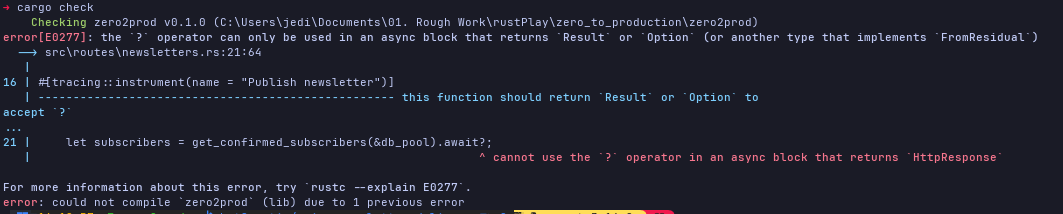


We need to add the appropriate error handling, similar to what we did in the previous chapter
```Rust
//! src/routes/newsletter.rs
// [...]
use actix_web::ResponseError;
use actix_web::http::StatusCode;

#[derive(Debug, thiserror::Error)]
pub emun PublishError{
    #[error(transparent)]
    UnexpectedError(#[from] anyhow::Error),
}

impl ResponseError for PublishError {
    fn status_code(&self) -> StatusCode {
        match self {
            PublishError::Unexpected(_) => StatusCode::INTERNAL_SERVER_ERROR,
        }
    }
}

#[tracing::instrument(/**/)]
pub async fn publish_newsletters(
    db_pool: web::Data::<PgPool>,
    _body: web::Json<BodyData>,
) -> Result<HttpResponse, PublishError> {
    let subscribers = get_confirmed_subscribers(&db_pool).await?;
    Ok(HttpResponse::Ok().finish())
}
```

We could implement a custom `Debug` for `PublishError` and call `error_chain_fmt` we defined in the previous chapter.  
However the default `Debug` + `anyhow::Error` achieves the same result with an error chain included.

With our error handling setup `cargo check` should succeed now.

## 09.07. Send Newsletter Emails

### 09.07.0. Overview

##### 09.07.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
`anyhow`'s `with_context` that we use in the `send_email` failure mode, 

_**Why?**_  
Because we are sending emails in an iteration we want to only do error string allocation in when an error is encountered.


_**Question?**_  
None

##### 09.07.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Naturally the next step here is to now send the newsletter issue to each email. To do this we make use of the  
`EmailClient` that we now pool into `publish_newsletter` via `web::Data<EmailClient>` and then call the `send_email`
on in it on every iteration as we loop through the `subscribers` collection.
```Rust
//! src/routes/newsletters.rs
// [...]
use crate::email_client::EmailClient;

#[tracing::instrument(/**/)]
pub async fn publish_newsletters(
    db_pool: web::Data<PgPool>,
    email_client: web::Data<EmailClient>,
    _body: web::Json<BodyData>,
) -> Result<HttpResponse, PublishError> {
    let subscribers = get_confirmed_subscribers(&db_pool).await?;
    for sub in subscribers {
        email_client.send_email(
            sub.email,
            &body.title,
            &body.content.html,
            &body.content.plain,
        )
        .await?;
    }

    Ok(HttpResponse::Ok().finish())
}
```

It seems that we have a couple of errors.

1. The query returns `email` as a string, however `send_email` requires a `SubscriberEmail` type.
2. We are unable to convert `send_email`'s `reqwest::Error` variant into `PublishError`

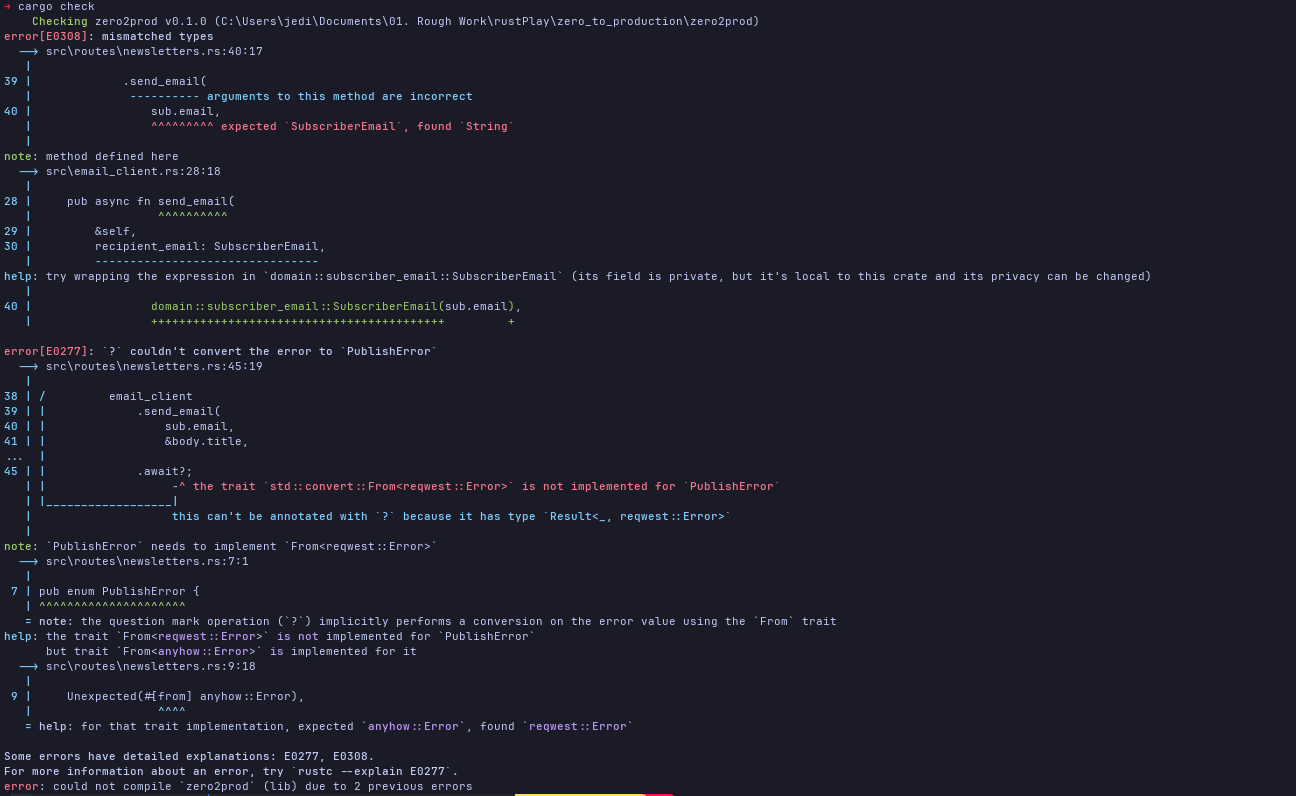

### 09.07.1. `context` vs `with_context`

##### 09.07.0.1. Deep Dive: Summarize, ELI5, Connect

We solve the second issue is easily resolvable by using `anyhow::Context`'s `with_context` which allows us to convert the underlying error type into an  
`anyhow::Error` while enriching the error with more contextual information.

`with_context` is a close relative of `context` that we used before in Chapter 8, the only difference being that `with_context` is lazy and the `format!`  
allocation will only occur when the operation fails.

For static operations `context` and `with_context` are identically but in dynamic situations where there maybe a runtime cost associated with allocation  
`with_context` earns its keep.

In this case because we are sending an email in each iteration we only want to allocated the failure string when we actually encounter an error. 

```Rust
//! src/routes/newsletters.rs
// [...]

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(
    /**/
) -> Result<HttpResponse, PublishError> {
    // [...]
    for sub in subscribers {
        email_client.send_email(
            sub.email,
            &body.title,
            &body.content.html,
            &body.content.plain,
        )
        .await
        .with_context(format!("Failed to send newsletter issue to {}", sub.email))?;
    }
}
```

## 09.08. Validation Of Stored Data

### 09.08.0. Overview

##### 09.08.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
In a high frequency deployment pipeline data stored in a DB can lead to _coupling old version of and new versions of an application_.  
In this case we might have _"valid email"_ by a prior criteria that has been updated to a more stricter validation protocal making some 
previous subscriber emails invalid.  

Use of `filter_map` in `get_confirmed_subscribers`

_**Why?**_  
This is an important consideration and is highlighted here when validating at insertion and validating at query time for applying business
logic to the data.

Great real world practical example of how `filter_map` would be used especially with a db query into a custom type.

_**Questions?**_  


##### 09.08.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Now to tackle the the issue with `sub.email` which expects a `SubscriberEmail` but found `String`.

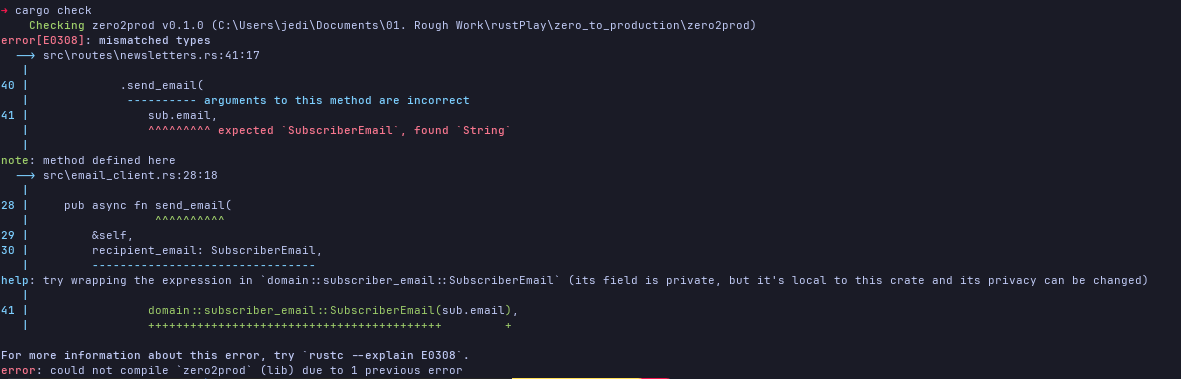

What if we change `ConfirmedSubscriber`'s `email` type from `String` to `SubscriberEmail`?
```Rust
//! src/routes/newsletters.rs
// [...]

struct ConfirmedSubscriber{
    email: SubscriberEmail
}

// [...]
```

We now we get the errors;
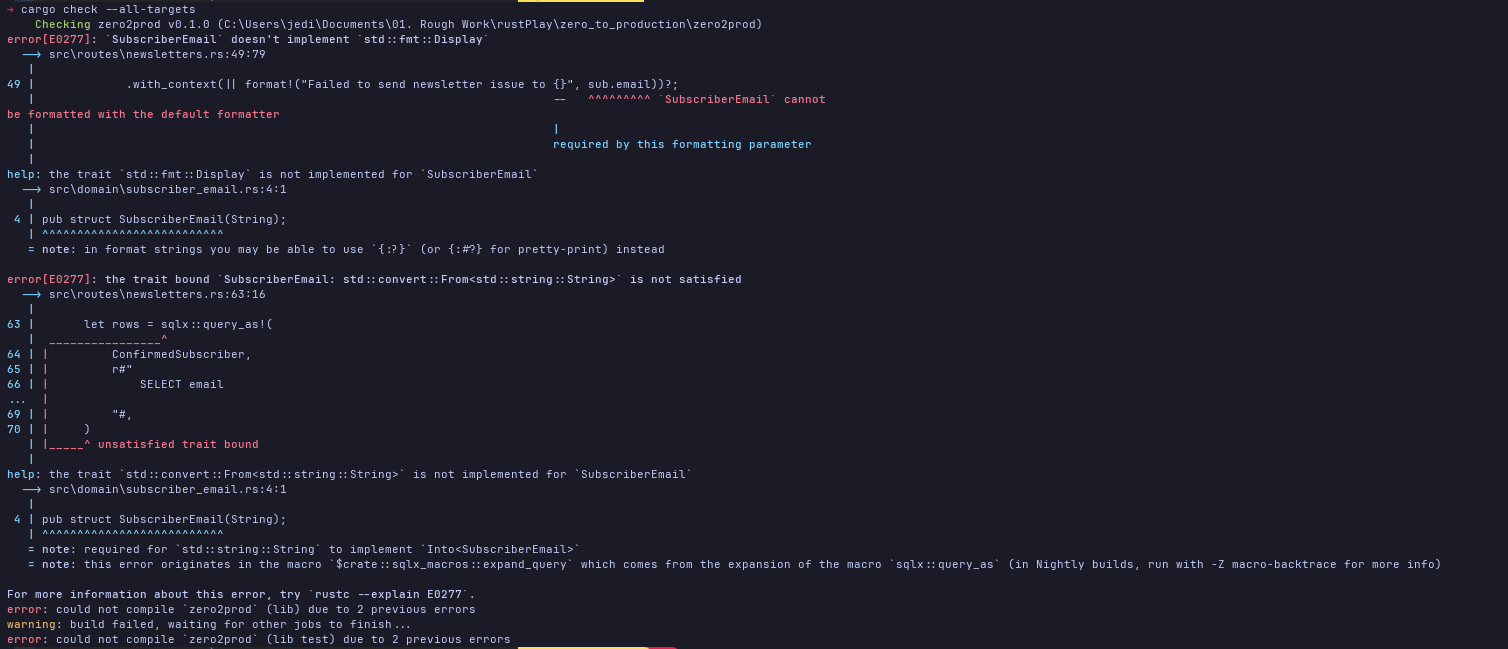

Boils down to 2 issues
1. How we handle `sub.email` in the `with_context`. Right now the issue is `Display` is not implemented for `SubscribeEmail`
   > We could easily fix this by either
   > - Implementing `Display` for `SubscriberEmail` _or_
   > - use `{:?}` formatting
   >
   > This will however uncover another issue that we'll discover later.
2. `query_as!` returns email as `String`, but we are mapping into `ConfirmedSubscriber` where email is of `SubscriberEmail` type.

Let's start with the second one and try a pattern we've used before
> When creating a new subscriber we used `FormData` for representing the raw data from the wire.  
> We then convert `FormData` to  `NewSubscriber` that is the validated representation.

Using `ConfirmedSubscriber` as the validated representation or the sqlx query we can use an intermediate type `Row` to represent the
raw query.

```Rust
//! src/routes/newsletters.rs
// [...]

struct ConfirmedSubscriber {
    email: SubscriberEmail,
}

#[tracing::instrument(/**/)]
async fn get_confirmed_subscribers(
    db_pool: &PgPool,
) -> Result<Vec<ConfirmedSubscriber>, anyhow::Error> {
    struct Row {
        email: String,
    }

    let rows = sqlx::query_as!(
        Row,
        r#"
            SELECT email
                FROM subscriptions
            WHERE status = 'confirmed';
        "#,
    )
    .fetch_all(db_pool)
    .await?;

    let confirmed_subscribers = rows
        .into_iter()
        .map(|r| ConfirmedSubscriber{
            // Just panic if email is invalid
            email: SubscriberEmail::parse(r.email).unwrap(),
        })
        .collect();
    Ok(confirmed_subscribers)
}
```

However, this raises the question of why are we doing a second round of validation for emails we already validated before inserting to the db.  
The reasoning is that the validation routine might change between insertion time and query time, meaning the rules that govern validation might  
not be the same introducing a drift that might go uncaught if we don't do validation at both points.

So whats the best way to do this? Above we are just panicking. What about filtering out invalid emails and just logging the error?
```Rust
//! src/routes/newsletters.rs
// [...]

#[tracing::instrument(/**/)]
async fn get_confirmed_subscribers(
    /**/
) -> Result<Vec<ConfirmedSubscriber>, anyhow::Error> {
    struct Row {
        email: String,
    }
    
    let rows = sqlx::query_as!(
        r#"
            SELECT email
                FROM subscriptions
            WHERE status = 'confirmed';
        "#,
    )
    .fetch(db_pool)
    .await?;

    let confirmed_subscribers = rows
        .into_iter()
        .filter_map(|r| match SubscriberEmail::parse(r.email) {
            Ok(email) => Some(ConfirmedSubscriber{ email }),
            Err(e) =>  {
                tracing::error!("A confirmed subscriber is using an invalid email address. \n{}.", e);
                None
            }
        })
        .collect();

    Ok(confirmed_subscribers)
}
```

However, we question if ths is the right place to handle an email parsing error; The pattern we've been using is that the _adapter_ `get_confirmed_subscribers`  
propagates the error to the caller who then decides what to do with the error.

### 09.08.1. Responsibility Boundaries

##### 09.08.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
Separation of concerns between were we call out that `get_confirmed_subscriber` is actually an **adapter** between the data layer and  
domain layer. Therefor it is inappropriate to apply filtering business logic and logging.  
This instead is the `publish_newsletter` handlers responsibility.

Tied to this is how we then update `get_confirmed_subscriber` return type to `Result<Vec<Result<ConfirmedSubscriber>, anyhow::Error>, anyhow::Error>`

_**Why?**_  
It is interesting to follow the authors reasoning as to why this is the preferable approach. And how this pattern generalizes to common architectural  
patterns (MVC, MVVM, MVP)

_**Questions?**_  

##### 09.08.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Instead or returning `Vec<ConfirmedSubscriber>` as the success variant for `get_confirmed_subscribers` we return 
`Vec<Result<ConfirmedSubscriber, anyhow::Error>, anyhow::Error>` in order to propagate the errors in in the vector and the the handler  
can decide what to do with the error for each single entry.
```Rust
//! src/routes/newsletters.rs
// [...]

#[tracing::instrument(/**/)]
async fn get_confirmed_subscribers(
    /**/
) -> Result<Vec<Result<ConfirmedSubscriber, anyhow::Error>>, anyhow::Error> {
    // [...]
    let confirmed_subscribers = rows
        .into_iter()
        .map(|r| match SubscriberEmail::parse(r.email) {
            Ok(email) => Ok(ConfirmedSubscriber{ email })
            Err(error) => Err(anyhow::anyhow!(error)),
        })
        .collect();
    Ok(confirmed_subscriber)
}
```

What does the compiler have for us now?  

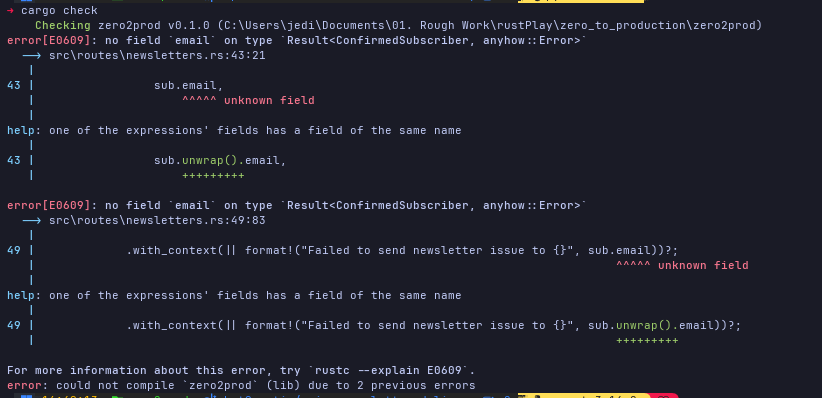

Alright our second error changes and seems like we have to call `unwrap` on `sub` to get it out of the `Ok` variant to access the `email` field  
in `publish_newsletter`.  
Lets handle the `Result` via a match instead.
```Rust
//! src/routes/newsletters.rs
// [...]

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(/**/) -> Result<HttpResponse, PublishError> {
    // [...]
    for sub in subscribers {
        match sub {
            Ok(subscriber) => email_client.send_email(
                    subscriber.email,
                    &body.title,
                    &body.content.html,
                    &body.content.plain,
                )
                .await
                .with_context(|| format!("Failed to send newsletter issue to {}", subscriber.email))?;
           Err(err) => {
                tracing::warn!(
                    error.cause_chain = ?err,
                    "Skipping confirmed subscriber\
                    Stored contact details are invalid.",
                );
           } 
        }
    }
    Ok(HttpResponse::Ok().finsih())
}
```

### 09.08.2.Follow The Compiler

##### 09.08.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
How we update `send_email` signature to accept a reference to `SubscriberEmail` as opposed to owning it.

_**Why?**_  
Always wondered why we did not use a reference here in the first place

_**Questions?**_  
Need to understand what `as_ref()` really does compared to `&example`?
> Some thing about how `as_ref()` allows us to be generic over the inner type alternatives. Explored [here](https://gemini.google.com/share/cf7f4fa3b009)

##### 09.08.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Now we are left with only the first error, around `subscriber.email` doesn't implement the `Display` trait.

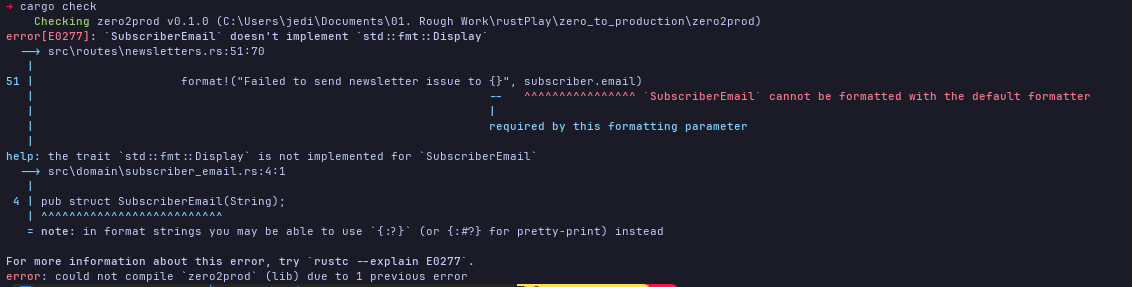


We could forward the `Display` implementation to `SubscriberEmail`'s inner `String` type. 
```Rust
//! src/domain/subscriber_email.rs
// [...]

impl std::fmt::Display for SubscriberEmail {
    fn fmt(&self, f: &mut std::fmt::Formatter<'_>) -> std::fmt::Result {
        self.0.fmt(f)
    }
}
```

Progress. We get a different error this time.

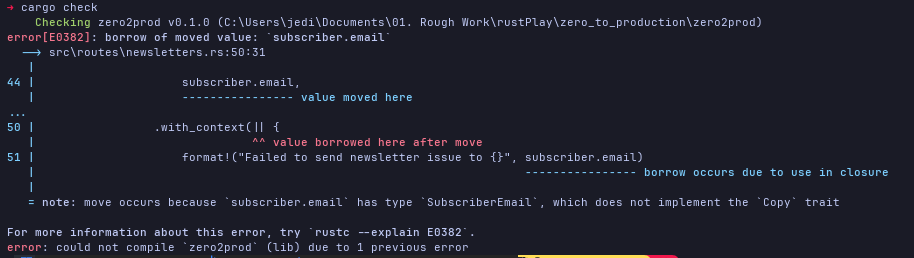


Long and short of it is that we can just use a reference to `SubscriberEmail` instead of owning it in the `email_client`'s   
`send_email`'s signature.
```Rust
//! src/email_client.rs
// [...]

impl EmailClient {
    pub fn new(/**/) -> Self { /**/ }

    pub async fn send_email (
        // [...]
        recipient_email: &SubscriberEmail,
        // [...]
    ) -> Result<(), reqwest::Error> {
        // [...]
    }
}
```

We then proceed to update all call sites to accept a reference to a subscriber email instead of an owned value.

### 09.08.3. Remove Come Boiler Plate

##### 09.08.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
Completing removing `struct Row {email: String}` from `get_subscribe_email` and reverting to using `sqlx::query!`

_**Why?**_  
Wondering if it was necessary to go through all that to come back to `sqlx::query!`. But at least we know how to achieve
a query and type maping at the same time.

_**Questions?**_  
None

##### 09.08.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
No need for an intermediate `Row` struct since a simple `sqlx::query!` returns email strings that we now parse in our mapping. We can remove it and just do the map directly
```Rust
//! src/routes/newsletters.rs
// [...]

#[tracing::instrument(/**/)]
async fn get_confirmed_subscribers(
    /**/
) -> Result<Vec<Result<ConfirmedSubscriber, anyhow::Error>>, anyhow::Error> {
    let confirmed_subscribers = sqlx::query!(
        r#"
            SELECT email
                FROM subscriptions
            WHWERE status = 'confirmed';
        "#,
    )
    .fetch_all(db_pool)
    .await?
    .into_iter()
    .map(|r| match SubscriberEmail::parse(r.email) {
        Ok(email) => Ok( ConfirmedSubscriber { email } ),
        Err(error) => Err( anyhow::anyhow!(error) )
    })
    .collect();

    Ok (confrimed_subscribers)
}
```

## 09.x. Axum Implementaion

No framework specific details. Straight forward implementation. Look at source

## 09.09. Limiitations Of Naive Approach

##### 09.09.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
The list of shortcomings. That one that stands out to me are
1. Security
2. Performance
3. Fault Tolerance

_**Why?**_  
Want to understand the Security and Fault Tolerance pieces in order to better scaffold a starter axum api project.

_**Questions?**_  
None

##### 09.09.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
We have basically completed our naive implementation of our newsletter delivery. However there are glaring gaps in
1. Security
2. Fault Tolerance
3. Performance
4. Retry Saftey
5. One shot newsletter issue - _Now review/edit before publish_

## 09.10. Summary

##### 09.10.0.0. Skimming: What did you notice and why? Any Questinos

_**What?**_  
This chapter is very palletable in a single sitting and not as information dense which I appreciate.

_**Why?**_  
Would be nice to see how to divide the next _Securing Our API_ into bite sized chunks that are more digestable  
because it is a long and information dense chapter.


_**Questions?**_  

##### 09.10.0.1. Deep Dive: Summarize, ELI5, Connect